# Entrenamiento de Gradient Boosting Regressor - ODEPA

Este notebook contiene el pipeline de entrenamiento y evaluación del modelo **Gradient Boosting Regressor** para predecir el precio promedio por kilogramo de productos agrícolas, utilizando la división cronológica de los datos (Entrenamiento con todo el 2025 y Prueba con la segunda mitad de 2026).

El preprocesamiento de variables categóricas se realiza de la siguiente manera:
- **One-Hot Encoding** para variables de baja cardinalidad (Subsector, Estacion).
- **Target Encoding** para variables de alta cardinalidad (Producto, Variedad / Tipo, Calidad, Origen, Mercado) para prevenir el sobreajuste y la maldición de la dimensionalidad.

## 1. Importación de Librerías

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 2. Carga de los Datasets Procesados

In [8]:
# Cargamos los conjuntos de datos en su ruta del proyecto
df_train = pd.read_csv("dataset/processed/dataset_entrenamiento.csv")
df_test = pd.read_csv("dataset/processed/dataset_prueba.csv")

print(f"Dataset de entrenamiento (2025): {df_train.shape[0]} registros")
print(f"Dataset de prueba (2026 - 2a mitad): {df_test.shape[0]} registros")

Dataset de entrenamiento (2025): 144018 registros
Dataset de prueba (2026 - 2a mitad): 27374 registros


## 3. Definición de Target y Features

In [9]:
# Variable objetivo (Precio por kilogramo)
y_train = df_train["Precio_Promedio_Por_Kilo"]
y_test = df_test["Precio_Promedio_Por_Kilo"]

# Variables explicativas
columnas_a_descartar = [
    "_id",
    "ID region",
    "Fecha",
    "Region",
    "Unidad de comercializacion",
    "Volumen",
    "Precio promedio",
    "Precio minimo",
    "Precio maximo",
    "Precio_Promedio_Limpio",
    "Precio_Promedio_Por_Kilo",
    "Dia_Semana_Nombre"
]

X_train = df_train.drop(columns=columnas_a_descartar)
X_test = df_test.drop(columns=columnas_a_descartar)

print("Variables predictoras finales:", list(X_train.columns))

Variables predictoras finales: ['Mercado', 'Subsector', 'Producto', 'Variedad / Tipo', 'Calidad', 'Origen', 'Volumen_Limpio', 'weight_kg', 'Mes', 'Dia_Semana', 'Estacion']


## 4. Clasificación de Variables y Preprocesamiento

In [10]:
# Variables categóricas de baja cardinalidad
cat_baja = ["Subsector", "Estacion"]

# Variables categóricas de alta cardinalidad
cat_alta = ["Mercado", "Producto", "Variedad / Tipo", "Calidad", "Origen"]

# Variables numéricas
num_cols = ["Volumen_Limpio", "weight_kg", "Mes", "Dia_Semana"]

# Preprocesador con ColumnTransformer
preprocesador = ColumnTransformer(
    transformers=[
        (
            "cat_baja",
            OneHotEncoder(handle_unknown="ignore"),
            cat_baja
        ),
        (
            "cat_alta",
            TargetEncoder(smooth="auto", cv=5, random_state=42),
            cat_alta
        ),
        (
            "num",
            "passthrough",
            num_cols
        )
    ]
)

## 5. Definición del Modelo y Pipeline

In [11]:
# Modelo de Gradient Boosting
modelo = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

# Construcción del Pipeline
pipeline = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", modelo)
])

## 6. Entrenamiento del Modelo

In [12]:
print("Entrenando el modelo Gradient Boosting Regressor (esto puede tardar unos minutos)...")
pipeline.fit(X_train, y_train)
print("¡Entrenamiento completado!")

Entrenando el modelo Gradient Boosting Regressor (esto puede tardar unos minutos)...


/home/francisco/Documentos/IngDatos/proyecto_grupo/prediccion_precio_promedio_hortifruticula/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


¡Entrenamiento completado!


## 7. Evaluación en el Conjunto de Prueba Temporal (2026)

In [13]:
# Predicciones sobre el conjunto de prueba
y_pred = pipeline.predict(X_test)

# Métricas cuantitativas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Resultados del Modelo en Conjunto de Prueba ---")
print(f"MAE : {mae:.2f} (Error promedio en pesos chilenos por kg)")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

--- Resultados del Modelo en Conjunto de Prueba ---
MAE : 263.84 (Error promedio en pesos chilenos por kg)
MSE : 178934.79
RMSE: 423.01
R²  : 0.8337


## 8. Visualización de Resultados

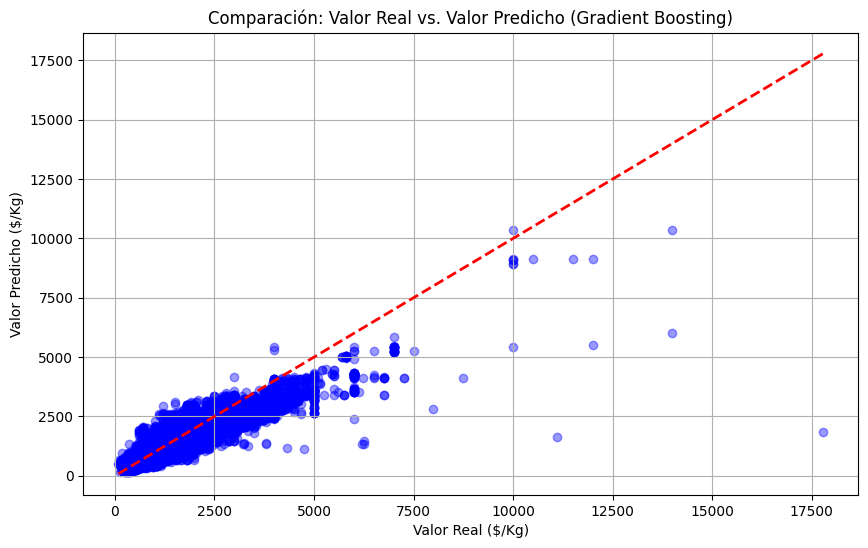

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Valor Real ($/Kg)")
plt.ylabel("Valor Predicho ($/Kg)")
plt.title("Comparación: Valor Real vs. Valor Predicho (Gradient Boosting)")
plt.grid(True)
plt.show()

## 9. Análisis de Importancia de Variables

--- Top 15 Variables Más Importantes ---
                                       Variable  Importancia
7                            cat_alta__Producto     0.700698
8                     cat_alta__Variedad / Tipo     0.056149
13                                     num__Mes     0.050524
9                             cat_alta__Calidad     0.043933
10                             cat_alta__Origen     0.038142
12                               num__weight_kg     0.033859
6                             cat_alta__Mercado     0.029073
2                   cat_baja__Estacion_Invierno     0.013976
4                  cat_baja__Estacion_Primavera     0.011581
5                     cat_baja__Estacion_Verano     0.010407
11                          num__Volumen_Limpio     0.005630
3                      cat_baja__Estacion_Otoño     0.002970
1   cat_baja__Subsector_Hortalizas y tubérculos     0.001850
0                    cat_baja__Subsector_Frutas     0.001170
14                              num__Dia_Sem

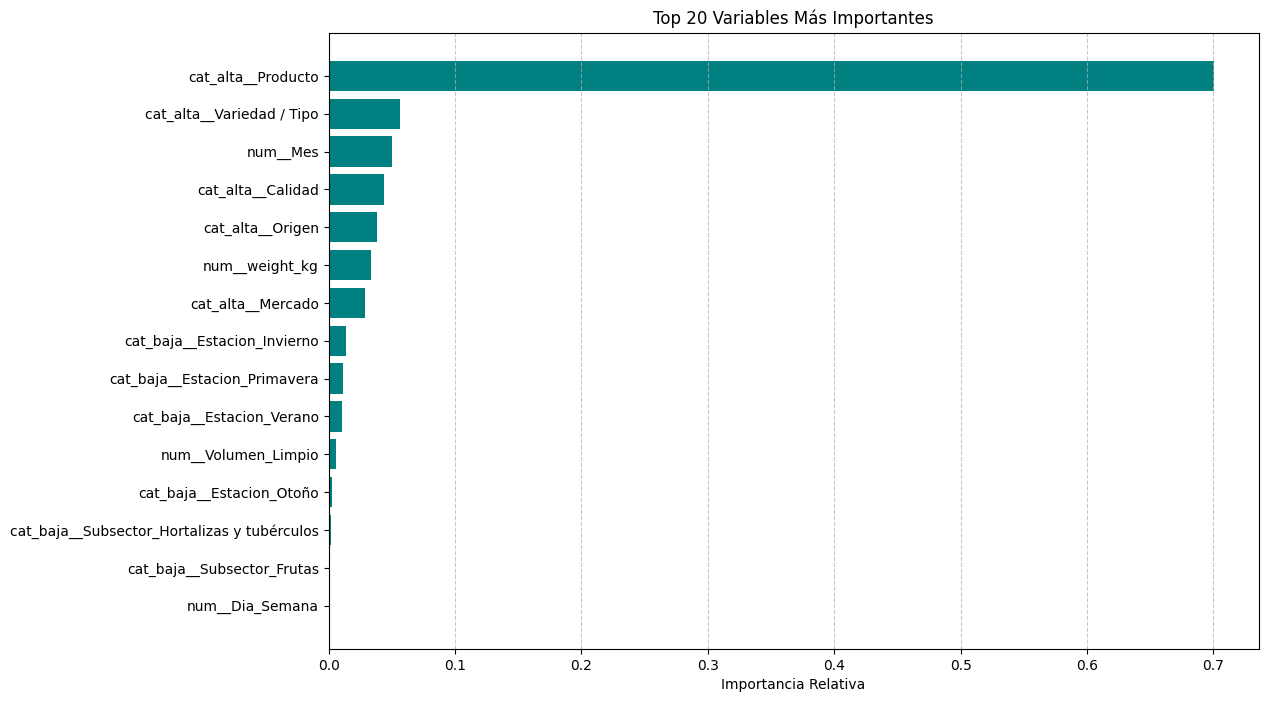

In [15]:
# Recuperamos nombres de variables tras el preprocesador
feature_names = pipeline.named_steps["preprocesamiento"].get_feature_names_out()
importances = pipeline.named_steps["modelo"].feature_importances_

importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": importances
}).sort_values(by="Importancia", ascending=False)

print("--- Top 15 Variables Más Importantes ---")
print(importance_df.head(15))

# Graficar importancia de variables
top20 = importance_df.head(20)
plt.figure(figsize=(12, 8))
plt.barh(top20["Variable"], top20["Importancia"], color="teal")
plt.title("Top 20 Variables Más Importantes")
plt.gca().invert_yaxis()
plt.xlabel("Importancia Relativa")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()